# Consigna

En este primer trabajo comenzaremos por diseñar un generador de señales que utilizaremos en las primeras simulaciones que hagamos. La primer tarea consistirá en programar una función que genere señales senoidales y que permita parametrizar:

la amplitud máxima de la senoidal (volts)
su valor medio (volts)
la frecuencia (Hz)
la fase (radianes)
la cantidad de muestras digitalizada por el ADC (# muestras)
la frecuencia de muestreo del ADC.
es decir que la función que uds armen debería admitir se llamada de la siguiente manera

tt, xx = mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs)


# Resultado

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 1000 ) -> tuple[np.ndarray,np.ndarray]:
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = vmax * np.sin(2*np.pi*ff*tt + ph) + dc
    xx = np.array(xx).reshape(nn,1)
    tt = tt.reshape(nn,1)

    return tt, xx

def mi_funcion_cuadrada(vmax = 1, dc = 0, ff = 1, duty = .5, nn = 100, fs = 1000 ) -> tuple[np.ndarray,np.ndarray] :
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = np.where(tt % (1/ff) < (1/ff) * duty, 1, -1)
    xx = vmax * xx + dc
    #signal.square(2* np.pi * ff* tt, duty)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return tt, xx

def mi_funcion_triangular(vmax = 1, dc = 0, ff = 1, nn = 1, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
    ts = 1/fs
    tt: np.ndarray = np.arange(stop= nn*ts, step=ts)
    T = 1/ff

    xx = [((vmax/T) * (i%T) + dc) for i in tt]
    #signal.sawtooth(2* np.pi * ff* tt, 0.5)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return tt, xx


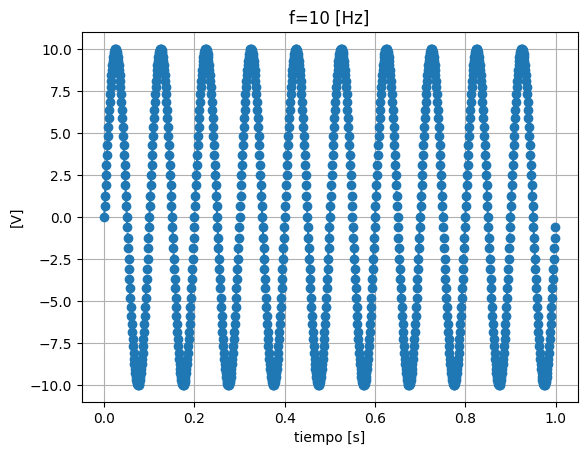

In [4]:
# Varaibles ############################################################
N = 1000
fs = 1000      #Hz
duty = .85
ff = 10

# Funciones ############################################################
tt, x1 = mi_funcion_triangular( vmax = 1, dc = 0, ff = ff, nn = N, fs = fs)
tt, x2 = mi_funcion_sen( vmax = 10, dc = 0, ff = ff, nn = N, ph = 0, fs = fs)
tt, x3 = mi_funcion_cuadrada( vmax = 1, dc = 0, ff = ff, duty = duty, nn = N, fs = fs)


# Grafico ############################################################
plt.title(f'f={ff} [Hz]')
plt.xlabel('tiempo [s]')
plt.ylabel('[V]')

#plt.plot(tt, x1,'x--')
plt.plot(tt, x2,'o--')
#plt.plot(tt, x3,'*--')

plt.grid()
plt.show()
